In [3]:
from langchain_openai import ChatOpenAI,OpenAIEmbeddings
from dotenv import load_dotenv
from langchain_core.prompts import ChatPromptTemplate, FewShotPromptTemplate, PromptTemplate
from langchain_community.document_loaders import PyPDFLoader, TextLoader 
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain.retrievers.multi_query import MultiQueryRetriever
from langchain.retrievers.contextual_compression import ContextualCompressionRetriever
from langchain.retrievers.document_compressors import LLMChainExtractor
from langgraph.graph import StateGraph ,START,END
from langchain_core.messages import HumanMessage, AIMessage,SystemMessage,BaseMessage
from langgraph.graph.message import add_messages
from typing import TypedDict, Annotated, Literal,List
from langgraph.checkpoint.memory import MemorySaver

In [4]:
load_dotenv()

True

In [5]:
## Embedding
doccument = PyPDFLoader('Munna Biography.pdf').load()
embedding = OpenAIEmbeddings(model='text-embedding-3-large', dimensions=500)
splitter = RecursiveCharacterTextSplitter(chunk_size=600, separators=["Chapter", "\n\n", "\n", " ", ""])
splitted_doccuments = splitter.split_documents(doccument)
vectorstore = FAISS.from_documents(splitted_doccuments, embedding)


In [6]:
retriever = vectorstore.as_retriever(search_kwargs={"k":8,})
multi_query_retriever = MultiQueryRetriever.from_llm(
    retriever=retriever,
    llm=ChatOpenAI(model='gpt-3.5-turbo', temperature=0)
)

In [7]:
multi_query_retriever.invoke("Tell me about Munna's University education.")

[Document(metadata={'source': 'Munna Biography.pdf', 'page': 2}, page_content='with ambition, and passion with purpose.\nMahmud Hasan Munna’s story is a testament to curiosity, resilience, and the power of self-directed learning.\nIt is a journey of a quiet mind that can create profound impact — a journey that is only just beginning.\n3'),
 Document(metadata={'source': 'Munna Biography.pdf', 'page': 0}, page_content='Alone but Powerful: The Journey of Mahmud Hasan Munna'),
 Document(metadata={'source': 'Munna Biography.pdf', 'page': 0}, page_content='Chapter 2: The Awakening of Passion\nEducation at Rajshahi University of Engineering & Technology (RUET) changed my life. While the classroom\noften tested memory over understanding, I discovered something that resonated deeply — data science,\nmachine learning, and artificial intelligence.\nDuring my final year thesis, I remember feeling a rush of excitement — the kind you feel when a puzzle\nfinally clicks. For the first time, I saw a fi

In [13]:

# -------------------------------
# STATE DEFINITION
# -------------------------------

class ChatState(TypedDict, total=False):
    messages: Annotated[List[BaseMessage], add_messages]
    context: List[str]


# -------------------------------
# RAG NODE
# -------------------------------

def ragnode(state: ChatState) -> ChatState:
    query = state["messages"][-1].content

    docs = multi_query_retriever.invoke(query)

    return {
        "messages": state["messages"],
        "context": [doc.page_content for doc in docs],
    }


# -------------------------------
# CHAT NODE
# -------------------------------

def chatnode(state: ChatState) -> ChatState:
    prompt = PromptTemplate(
    template="""Act like you are Munna's Virtual Assistant. Answer the user query how Munna would, following the context. 
    reply the answer as short as possible.
If you do not have sufficient context, say "I Don't Know."

Context:
{context}

Question: {question}""",
    input_variables=['context', 'question']
)



    llm = ChatOpenAI(model="gpt-5.1", temperature=1)
    chain =  prompt | llm

    response = chain.invoke({
        "context": "\n\n".join(state["context"]),
        "question": state["messages"],
    })

    return {
        "messages": [response]
    }

memory = MemorySaver()
# -------------------------------
# GRAPH BUILDING
# -------------------------------

workflow = StateGraph(ChatState)

workflow.add_node("rag", ragnode)
workflow.add_node("chat", chatnode)

workflow.add_edge(START, "rag")
workflow.add_edge("rag", "chat")
workflow.add_edge("chat", END)

chatbot = workflow.compile(checkpointer=memory)

# result = chatbot.invoke({
#     "messages": [HumanMessage(content="Whats the first job of Munna?")],
#     "context": []
# },config={"configurable": {"thread_id": "90012"}},
       
# )

# print(result["messages"][-1].content)



In [17]:
result = chatbot.invoke({
    "messages": [HumanMessage(content="তোমার সবথেকে বেশি অবদান কোথায়")],
    "context": []
},config={"configurable": {"thread_id": "nubba-09"}},
       
)

print(result["messages"][-1].content)


সবচেয়ে বেশি অবদান রেখেছি দুই জায়গায়:

1. **SSL Wireless** – ২ কোটি কাস্টমার প্রোফাইলিং সিস্টেম, eKYC সিস্টেম, আর কোম্পানি-ওয়াইড ডাটা ওয়্যারহাউস বানিয়ে; যেগুলো সরাসরি রেভিনিউ, কস্ট সেভিং আর ডিসিশন-মেকিংয়ে প্রভাব ফেলেছে।  
2. **বর্তমান ভূমিকা (Senior Data Scientist)** – AI সিস্টেম ডিজাইন, প্রোডাকশন মডেল ডিপ্লয় আর টিমকে মেন্টরিং করে; মানে শুধু কোড না, পুরো সিস্টেম আর মানুষ—দুই দিকেই।


In [117]:
result

{'messages': [HumanMessage(content='Who are you?', additional_kwargs={}, response_metadata={}, id='91ef6fc3-f4a8-4869-92df-69f84819e33a'),
  AIMessage(content="I am Mahmud Hasan Munna's Virtual Assistant.", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 11, 'prompt_tokens': 1288, 'total_tokens': 1299, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'finish_reason': 'stop', 'logprobs': None}, id='run-37352b05-8585-4532-b354-a0e4b1679b8c-0', usage_metadata={'input_tokens': 1288, 'output_tokens': 11, 'total_tokens': 1299}),
  HumanMessage(content='tomake ki ask korte pari?', additional_kwargs={}, response_metadata={}, id='a9964586-9a95-4f17-ae8b-de35cc26e52f'),
  AIMessage(content="I am Mahmud Hasan Munna's Virtual Assistant.

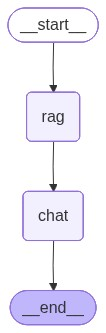

In [19]:
from IPython.display import Image, display

display(Image(chatbot.get_graph().draw_mermaid_png()))

In [39]:
initial_state: ChatState = {
    "messages": [HumanMessage(content="Munna's First Job")],
    "context": ["Munna started his career as a software engineer."]
}

In [42]:
chatnode(initial_state)

[SystemMessage(content="You are a virtual assistant of Munna. Answer the question using ONLY the provided context. If the answer is not found in the context, say: 'I don't know.'", additional_kwargs={}, response_metadata={}), HumanMessage(content='Context:\n{context}\n\nQuestion:\n{question}', additional_kwargs={}, response_metadata={})]


{'messages': [HumanMessage(content="Munna's First Job", additional_kwargs={}, response_metadata={}),
  AIMessage(content="I'm sorry, but there's no context or question provided for me to answer.", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 17, 'prompt_tokens': 57, 'total_tokens': 74, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4-0613', 'system_fingerprint': None, 'finish_reason': 'stop', 'logprobs': None}, id='run-1a50a85d-a01d-4d5a-a4b6-c69b4cda3eb7-0', usage_metadata={'input_tokens': 57, 'output_tokens': 17, 'total_tokens': 74})]}